# Predicting CeX Used Game Prices with Random Forest 

## Objective
Can machine learning predict used game prices from unseen CeX listings?

## Background

CeX publicly lists prices, cash values and voucher values for used video games across multiple platforms.

For this project, we will only consider the cash values of PS5 games as the methodology is reproducible for every console platform.

This project explores whether a machine learning model can predict retail game prices using:
- title information
- franchise patterns
- basic metadata

The project also investigates the limitations of pricing models when important market variables, such as sales data, historical pricing, etc are missing.

Additional remark: I extracted the data from CeX's website myself.

In [5]:
# Importing the relevant libraries

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, r2_score

## Loading the Dataset

The dataset contains:
- game titles
- prices
- ratings
- trade-in information

In [45]:
df = pd.read_csv("uk.csv")

## Data Inspection 

In [49]:
# df.head # way too messy
df.shape # too many unnecessary columns
df.columns
# df.info()
# df.describe()


Index(['card-img href', 'card-img src', 'card-rating', 'line-clamp',
       'product-main-price', 'line-clamp href 2', 'md-text-base', 'md-text-xs',
       'md-text-base 2', 'md-text-xs 2'],
      dtype='object')

# Cleaning and Formatting the Data

The data has currency symbols which will lead to the ML algorithm becoming confused - we must remove these. We also need to deal with missing/extraneous values of both types - numerical and categorical so that the ML algorithm won't get confused.

In [ ]:
# Fix column names

df = df.rename(columns={"product-main-price": "Price", "md-text-base": "Voucher Value", "md-text-base 2": "Cash Value", "line-clamp": "Title", "card-rating": "Rating"})
df = df.drop(columns={"card-img href", "card-img src", "line-clamp href 2", "md-text-xs", "md-text-xs 2"})

In [54]:
# Format the data entries

df["Price"] = (
    df["Price"].astype(str).str.replace("£", " ", regex = False).astype(float))
df["Voucher Value"] = (
    df["Voucher Value"].astype(str).str.replace("£", " ", regex = False).astype(float))
df["Cash Value"] = (
    df["Cash Value"].astype(str).str.replace("£", " ", regex = False).astype(float))

# Remove duplicates
df = df.drop_duplicates()

# Handle missing entries
df.isnull().sum() # It appears that the first 85 games do not have voucher / cash value information


Rating           338
Title              0
Price              0
Voucher Value     85
Cash Value        85
Title Length       0
dtype: int64

## Feature Engineering



Additional features have to be engineered in clever ways to provide the ML algorithm will the best possible predictive structure. This can be done by the following:
- Franchise extraction: the model could identify patterns and spot more expensive franchises such as "Call of" referring to Call of Duty.
- Title length: it is most likely that the more expensive/well-known games would have longer title lengths. It is far more plausible to see "God of War Ragnarok: Collector's Edition" instead of "FIFA 22: Remastered With DLC".
- Games without DLC are more likely to be priced cheaper at a discounted value

In [75]:
df["Title Length"] = df["Title"].str.len()
df.head(10)

,Rating,Title,Price,Voucher Value,Cash Value,Title Length,No DLC,Franchise
0,4.8,God of War Ragnarok (No DLC),22.0,NaN,NaN,28,1,God of
1,4.7,Horizon Forbidden West (No DLC),22.0,NaN,NaN,31,1,Horizon Forbidden
2,4.7,Ghost of Yotei,52.0,NaN,NaN,14,0,Ghost of
3,4.7,"Last of Us Part II Remastered, The",28.0,NaN,NaN,34,0,Last of
4,3.9,"Callisto Protocol, The",6.0,NaN,NaN,22,0,"Callisto Protocol,"
5,4.6,Spider-Man: Miles Morales (No DLC),15.0,NaN,NaN,34,1,Spider-Man: Miles
6,NaN,WWE 2K25 (No DLC),22.0,NaN,NaN,17,1,WWE 2K25
7,NaN,Assassin's Creed Shadows (No DLC),30.0,NaN,NaN,33,1,Assassin's Creed
8,4.2,Mafia: The Old Country,25.0,NaN,NaN,22,0,Mafia: The
9,4.2,Far Cry 6 (No DLC),10.0,NaN,NaN,18,1,Far Cry


From the first ten entries, it appears that a lot of title lengths are affected by Cex's addition of "(No DLC)". This is a huge problem as the addition of these eight characters increases the title length leading to a more expensive rating, however these games would have a discounted value due to their "incomplete" nature.

In [ ]:
# A solution to this would be to count all of the games marked with having no DLC.
df["No DLC"] = (
    df["Title"].str.contains("(No DLC)", case = False, na = True).astype(int)
)
# df 

In [77]:
# Highlighting the franchises
df['Franchise'] = (
    df['Title']
    .astype(str)
    .str.replace(r'\(.*?\)', '', regex=True)
    .str.split()
    .str[:2]
    .str.join(' ')
)
# Note: This doesn't look very clean to the human eye but it would allow for there to be pattern recognition during the machine learning step.
# Example: Model may notice that "God of" games are priced at a more premium price.

df.head(10)


,Rating,Title,Price,Voucher Value,Cash Value,Title Length,No DLC,Franchise
0,4.8,God of War Ragnarok (No DLC),22.0,NaN,NaN,28,1,God of
1,4.7,Horizon Forbidden West (No DLC),22.0,NaN,NaN,31,1,Horizon Forbidden
2,4.7,Ghost of Yotei,52.0,NaN,NaN,14,0,Ghost of
3,4.7,"Last of Us Part II Remastered, The",28.0,NaN,NaN,34,0,Last of
4,3.9,"Callisto Protocol, The",6.0,NaN,NaN,22,0,"Callisto Protocol,"
5,4.6,Spider-Man: Miles Morales (No DLC),15.0,NaN,NaN,34,1,Spider-Man: Miles
6,NaN,WWE 2K25 (No DLC),22.0,NaN,NaN,17,1,WWE 2K25
7,NaN,Assassin's Creed Shadows (No DLC),30.0,NaN,NaN,33,1,Assassin's Creed
8,4.2,Mafia: The Old Country,25.0,NaN,NaN,22,0,Mafia: The
9,4.2,Far Cry 6 (No DLC),10.0,NaN,NaN,18,1,Far Cry


## Exploratory Data Analysis

In [78]:
def eda_games(df):
    print(f"Average price: £{round(df["Price"].mean(), 2)}")
    print(f"Middle price: {df["Price"].median()}")
    print(f"Games containing DLC: {sum(df["No DLC"] == 0)}")
    print(f"Proportion of games containing DLC: {round(100 * sum(df["No DLC"] == 0) / df.shape[0], 2)}%")

eda_games(df)

Average price: £20.59
Middle price: 18.0
Games containing DLC: 690
Proportion of games containing DLC: 84.56%


In [80]:
# Games from most expensive to least
most_expensive_games = df.sort_values("Price", ascending = False).head(10)
most_expensive_games



,Rating,Title,Price,Voucher Value,Cash Value,Title Length,No DLC,Franchise
600,NaN,"Baldur's Gate 3 Deluxe Ed. w/3x CD, Poster, Ma...",150.0,103.0,85.0,74,0,Baldur's Gate
676,NaN,"Terminator 2D: NO FATE Col. Ed. w/Weight, Toke...",120.0,78.0,55.0,74,0,Terminator 2D:
287,4.5,Microsoft Flight Simulator 2024,80.0,55.0,45.0,31,0,Microsoft Flight
410,NaN,"Crimson Desert Deluxe Edition w/Steelbook,Broo...",72.0,53.0,46.0,73,1,Crimson Desert
125,4.5,Indiana Jones & The Great Circle (No DLC),70.0,48.0,39.0,41,1,Indiana Jones
781,NaN,Legend of Heroes: Trails Beyond the Horizon De...,65.0,44.0,37.0,73,1,Legend of
104,NaN,Saros,62.0,45.0,39.0,5,0,Saros
100,4.8,Resident Evil Requiem (No DLC),60.0,41.0,34.0,30,1,Resident Evil
810,NaN,Tomb Raider I-III Remastered: Deluxe Ed. w/Boo...,58.0,37.0,26.0,63,0,Tomb Raider
733,5.0,Horizon Forbidden West: Complete Edition (2 Di...,55.0,35.0,25.0,56,1,Horizon Forbidden


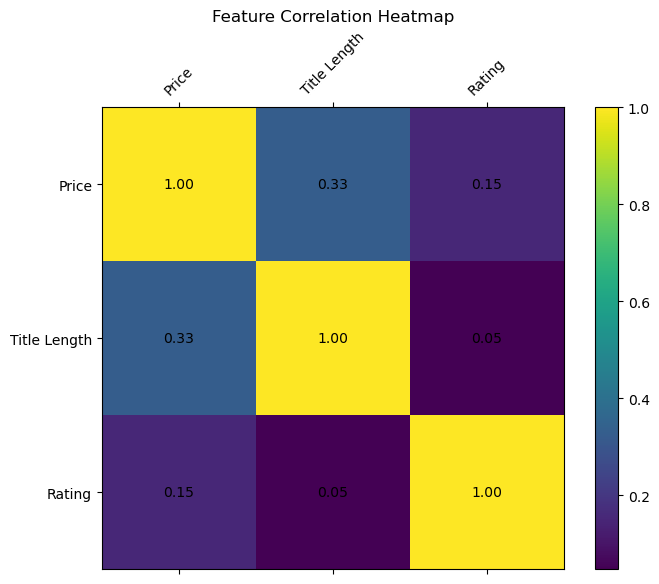

In [81]:
import matplotlib.pyplot as plt

corr = df[
    [
        'Price',
        'Title Length',
        'Rating'
    ]
].corr()

fig, ax = plt.subplots(figsize=(8,6))

cax = ax.matshow(corr)

# Axis labels
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))

ax.set_xticklabels(corr.columns, rotation=45)
ax.set_yticklabels(corr.columns)

# Add correlation values
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(
            j,
            i,
            f"{corr.iloc[i, j]:.2f}",
            va='center',
            ha='center'
        )

fig.colorbar(cax)

plt.title('Feature Correlation Heatmap')

plt.savefig(
    '02_correlation_heatmap.png',
    bbox_inches='tight'
)

plt.show()

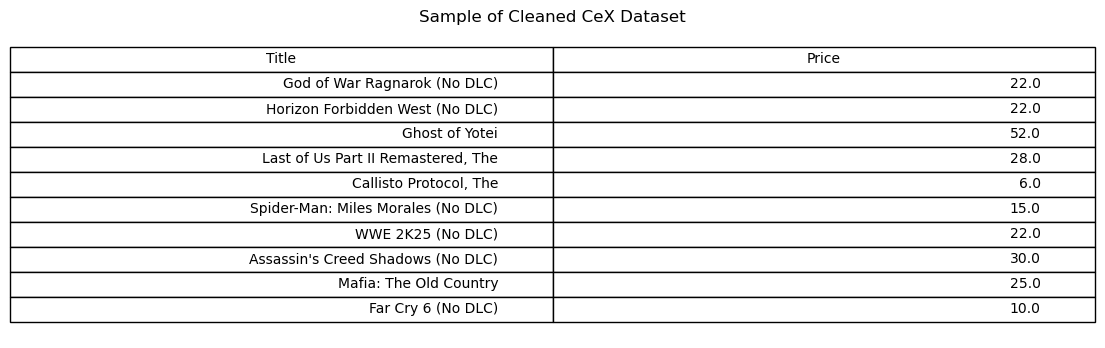

In [82]:
sample = df[
    ['Title', 'Price']
].head(10)

fig, ax = plt.subplots(figsize=(14,4))

ax.axis('off')


table = ax.table(
    cellText=sample.values,
    colLabels=sample.columns,
    loc='center'
)


table.auto_set_font_size(False)

table.set_fontsize(10)

table.scale(1, 1.5)

plt.title('Sample of Cleaned CeX Dataset')

plt.savefig('01_dataframe_preview.png', bbox_inches='tight')

plt.show()

## Train-Test Split

In [74]:
# We are trying to predict price using other pieces of available data.

y = df["Price"]
X = df[
    [
        'Rating',
        'Title Length',
        'No DLC',
        'Franchise'
    ]
]
# I set gamma to 20% which means that the model trains on 80% of the data and tests on 20%. 
# I believe that this is an appropriate gamma value, but I have left it incase you want to change the numbers!
# Remark: Training data: 100*(1 - gamma) %, Test data: 100*gamma %
gamma = 0.2
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=gamma,
    random_state=42
)

## Building the preprocessing pipeline

### Separate the numerical and categorical columns

In [66]:
numerical_cols =  [
        'Rating',
        'Title Length',
        'No DLC',
    ]

categorical_cols = [
    'Franchise'
]

# I replaced any blank numeric values with the median - this is a better choice than the mean as the median isn't affected by extreme values!
# The Machine Learning only works well with normalised data so I am converting it using StandardScaler()!
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
# I replaced any blank categorical values with the modal value - it is one of the best ways to deal with the missing entries!
# Incase the Machine learning algorithm sees something it doesn't recognise, I added an encoder to prevent it from getting stuck!
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

### Combine the preprocessing

In [67]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

## Random Forest Model Pipeline

In [68]:
random_forest_model = Pipeline(steps = [
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators = 200,
        random_state = 42)
    )
])

## Train the Random Forest Model

In [69]:
random_forest_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Predict unseen game prices

In [70]:
predictions = random_forest_model.predict(X_test)

## Model Evaluation

In [71]:
mae = mean_absolute_error(y_test, predictions)
print(f"The Mean Absolute Error tells us that on average, the model's predictions are off by £{round(mae, 2)}.")

The Mean Absolute Error tells us that on average, the model's predictions are off by £8.26.


In [72]:
r2 = r2_score(y_test, predictions)
def r2_explanation(r2):
    if r2 > 0.95:
        return "model is perfect"
    elif r2 > 0.65:
        return "model is strong"
    elif r2 > 0.35:
        return "model is moderate"
    else:
        return "model is weak"

print(f"R Squared is approximately {round(r2, 2)}, which means that the {r2_explanation(r2)}.")

R Squared is approximately 0.18, which means that the model is weak.


In [73]:
results = pd.DataFrame({
    'actual': y_test,
    'predicted': predictions
})

results.to_csv("predictions.csv", index=False)

## Final remarks

The model was weak because there wasn't enough relevant data - release year, genre, sales, demand, historical pricing, etc. I intend to repeat this project with a more advanced dataset and to inspect the machine learning algorithm.


Visuals

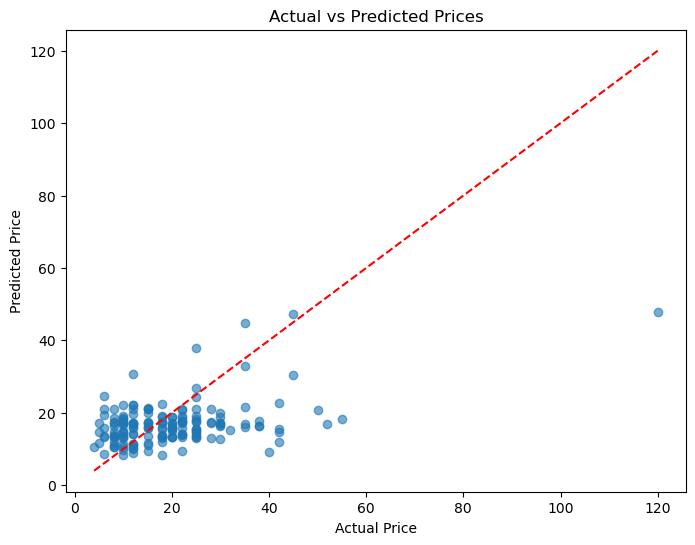

In [39]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    predictions,
    alpha=0.6
)

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')

plt.title('Actual vs Predicted Prices')


plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)


plt.savefig('04_actual_vs_predicted.png', bbox_inches='tight')

plt.show()